# Compute DC Potential

In [7]:
## From dc_potential.ipynb
import constants as c
import numpy as np
import pandas as pd
import math
import matplotlib.pyplot as plt
from scipy.stats import maxwell
vk = c.vk
vrf = c.vrf
z_offset = c.z0
xy1k = c.xy1k
xy2k = c.xy2k
pi = math.pi
um = c.um
cm = c.cm
mm = c.mm
K = c.K
e = c.e
z_min_valid = -c.ion_height
z_margin = 1.0e-6   # optional safety margin away from electrode plane

## Functions
# (x,y,z) = coordinate of sample
# (xik,yik,z0) = ith corner coordinates of kth electrode
# vk = voltage applied to kth electrode
def potential_term(x,y,z,xik,yik,z0):
    num = (xik-x)*(yik-y); # numerator
    den = (z-z0)*math.sqrt((z-z0)**2+(xik-x)**2+(yik-y)**2); # denominator
    return num/den

def dc_potential_single_electrode(x,y,z,x1k,y1k,x2k,y2k,z0,vk):
    term1 = math.atan(potential_term(x,y,z,x2k,y2k,z0))
    term2 = math.atan(potential_term(x,y,z,x1k,y2k,z0))
    term3 = math.atan(potential_term(x,y,z,x2k,y1k,z0))
    term4 = math.atan(potential_term(x,y,z,x1k,y1k,z0))
    return (vk/(2*math.pi))*(term1-term2-term3+term4)

def dc_potential_total(x,y,z,xy1k=c.xy1k,xy2k=c.xy2k,z0=c.z0,vk=c.vk):
    # extract individual (xik,yik),vk values from array
    # all arrays must be same size
    # sum potentials from all electrodes
    z = z+c.ion_height # account for ion height
    pot = 0
    for i in range (0,len(c.vk)):
        x1k = xy1k[i][0]
        y1k = xy1k[i][1]
        x2k = xy2k[i][0]
        y2k = xy2k[i][1]
        v = vk[i]
        if(i==19 or i==39): # make sure Q39-40 are on the M4 layer
            new_pot = dc_potential_single_electrode(x,y,z,x1k,y1k,x2k,y2k,0,v); # z0=0 for Q39-40
        else:
            new_pot = dc_potential_single_electrode(x,y,z,x1k,y1k,x2k,y2k,z0,v); # z0 = -11.8um for Q1-38
        pot+=new_pot
    return pot

# Compute RF Potential

In [8]:
## From rf_potential.ipynb
## Functions
## Compute Pseudopotential (J)
"""
# Method 1: numerical RF gradient
Ex,Ey,Ez = np.gradient(-1*phi_rf,res,res,res); # Electric field components
E_squared = Ex**2+Ey**2+Ez**2; # Electric field strength squared
pseudo2 = (c.Z**2*c.e**2)/(4*c.m*c.omega**2)*E_squared
# pseudo_reshaped = pseudo.reshape(int(2*x_max/res+1),-1)
"""
# Method 2: analytical RF gradient
def divatan(up,down):
    #This is d(arctan2(up,down))/ddown up to a minus sign. It's useful for the pseudo-potential
    return up/(up**2+down**2)
def divatanup(up,down):
    #This is d(divatan(up,down))/dup
    return (down**2-up**2)/(up**2+down**2)**2
def divatandown(up,down):
    #This is d(divatan(up,down))/ddown
    return -2*up*down/(up**2+down**2)**2
def pseudopotential(x,y,z,m,Z,q=c.e,omrf=c.omega,VRF=c.vrf,ymin=c.y11,yedge1=c.y21,yedge2=c.y12,ymax=c.y22):
    #this is the pseudo potential, which is Z^2*(Div[PhiRF]/cos(om*t))^2/(4m*omega^2)
    z = z+c.ion_height # account for ion height
    divypart=divatan(z,yedge2-y)-divatan(z,yedge1-y)+divatan(z,ymin-y)-divatan(z,ymax-y)
    divzpart=divatan(yedge2-y,z)-divatan(yedge1-y,z)+divatan(ymin-y,z)-divatan(ymax-y,z)
    return ((Z**2*q**2)/(4*m*omrf**2)) * (VRF/math.pi)**2 * (divypart**2+divzpart**2)

In [9]:
## Compute Full Potential Energy
def coulomb_pot(x,y,z,eps,Z=c.Z):
    return c.K*eps*Z*c.e**2/np.sqrt(x**2+y**2+z**2)
def potential_energy(xyz, m_dm, eps, component="total"):
    x, y, z = xyz[0], xyz[1], xyz[2]
    dc = eps * c.e * dc_potential_total(x, y, z)
    pseudo_rf = pseudopotential(x, y, z, m_dm, eps)
    coulomb = coulomb_pot(x, y, z, eps)
    if component == "dc":
        return dc
    elif component == "pseudo_rf":
        return pseudo_rf
    elif component == "coulomb":
        return coulomb
    elif component == "trap":
        return dc + pseudo_rf
    elif component == "total":
        return dc + pseudo_rf + coulomb
    elif component == "all":
        return dc, pseudo_rf, coulomb
    else:
        raise ValueError(f"Unknown potential component: {component}")

# Compute RF/DC Force

In [10]:
"""
xyz : ndarray, shape (n, 3)
        Particle positions.
"""
# RF pseudo-force
def FRF(xyz,m,Z,q=c.e,omrf=c.omega,VRF=c.vrf,ymin=c.y11,yedge1=c.y21,yedge2=c.y12,ymax=c.y22):
    xyz = np.asarray(xyz, dtype=float)
    if xyz.ndim != 2 or xyz.shape[1] != 3:
        raise ValueError("xyz must have shape (n, 3)")
    x = xyz[:, 0]
    y = xyz[:, 1]
    z = xyz[:, 2] + c.ion_height # Take into account ion height
    m = float(np.asarray(m).ravel()[0])
    Z = float(np.asarray(Z).ravel()[0])
    q = float(np.asarray(q).ravel()[0])
    omrf = float(np.asarray(omrf).ravel()[0])
    VRF = float(np.asarray(VRF).ravel()[0])
    #this is the pseudo potential, which is Z^2*(Div[PhiRF]/cos(om*t))^2/(4m*omega^2)
    divypart=divatan(z,yedge2-y)-divatan(z,yedge1-y)+divatan(z,ymin-y)-divatan(z,ymax-y)
    divzpart=divatan(yedge2-y,z)-divatan(yedge1-y,z)+divatan(ymin-y,z)-divatan(ymax-y,z) 
    divyparty=-2*divypart*(divatandown(z,yedge2-y)-divatandown(z,yedge1-y)+divatandown(z,ymin-y)-divatandown(z,ymax-y)) 
    divypartz=2*divypart*(divatanup(z,yedge2-y)-divatanup(z,yedge1-y)+divatanup(z,ymin-y)-divatanup(z,ymax-y)) 
    divzparty=-2*divzpart*(divatanup(yedge2-y,z)-divatanup(yedge1-y,z)+divatanup(ymin-y,z)-divatanup(ymax-y,z)) 
    divzpartz=2*divzpart*(divatandown(yedge2-y,z)-divatandown(yedge1-y,z)+divatandown(ymin-y,z)-divatandown(ymax-y,z)) 
    return -1*((VRF*Z*q)/(2*pi*np.sqrt(m)*omrf))**2*np.column_stack([divypartz*0, divzparty+divyparty, divzpartz+divypartz])

# DC force
def divatan(up,down):
    #This is d(arctan2(up,down))/ddown up to a minus sign. It's useful for the pseudo-potential
    return up/(up**2+down**2)
def divatanup(up,down):
    #This is d(divatan(up,down))/dup
    return (down**2-up**2)/(up**2+down**2)**2
def divatandown(up,down):
    #This is d(divatan(up,down))/ddown
    return -2*up*down/(up**2+down**2)**2

def anatangrad(xi,yi,xyz,v): # gradient term of DC potential
    xyz = np.asarray(xyz, dtype=float)
    x = xyz[:, 0]
    y = xyz[:, 1]
    z = xyz[:, 2]
    dy=y-yi
    dx=x-xi
    r = np.sqrt(dx**2+dy**2+z**2); # added distance
    dry2=z**2+dy**2
    drx2=z**2+dx**2
    divy=z*dx/(r*dry2); # divide by factor r
    divz=-dy*dx*(1/dry2+1/drx2)/r; # divide by factor r
    divx=z*dy/(r*drx2); # divide by factor r
    return (v/(2*np.pi))*np.column_stack([divx, divy, divz])

def FDC_single(x1,y1,x2,y2,xyz,v,Z,q=c.e):
    return -Z*q * (anatangrad(x2,y2,xyz,v)-anatangrad(x2,y1,xyz,v)-anatangrad(x1,y2,xyz,v)+anatangrad(x1,y1,xyz,v))

def FDC(xyz, m, Z, q=c.e, omrf=c.omega,
        ymin=c.y11, yedge1=c.y21, yedge2=c.y12, ymax=c.y22):
    xyz = np.asarray(xyz, dtype=float)
    if xyz.ndim != 2 or xyz.shape[1] != 3:
        raise ValueError("xyz must have shape (n, 3)")
    z_original = xyz[:, 2].copy() + c.ion_height # Take into account ion height
    force = np.zeros_like(xyz)
    for k in range(0, 40):
        xyz_k = xyz.copy()
        if (k != 19 and k != 39):
            xyz_k[:, 2] = z_original - z_offset  # keep scalar math
        else:
            xyz_k[:, 2] = z_original
        (x1k, y1k) = xy1k[k]
        (x2k, y2k) = xy2k[k]
        # enforce scalar on vk[k]
        v_k = float(np.asarray(vk[k]).ravel()[0])
        force_single = FDC_single(x1k, y1k, x2k, y2k, xyz_k, v_k, Z, q=q)
        # check shape of force_single 
        force_single = np.asarray(force_single, dtype=float)
        if force_single.shape != xyz.shape:
            raise ValueError(
                f"FDC_single returned unexpected shape {force_single.shape}; "
                f"expected {xyz.shape} at k={k}"
            )
        force += force_single
    return force

def force(xyz, m_dm, eps, component="total"):
    xyz = np.asarray(xyz, dtype=float)

    single_input = False
    if xyz.ndim == 1:
        xyz = xyz.reshape(1, 3)
        single_input = True

    if xyz.ndim != 2 or xyz.shape[1] != 3:
        raise ValueError("xyz must have shape (n, 3) or (3,)")

    dc_force = FDC(xyz, m_dm, eps)
    pseudo_force = FRF(xyz, m_dm, eps)

    r = np.linalg.norm(xyz, axis=1)

    coulomb_force = np.full_like(xyz, np.nan, dtype=float)
    good = r > 0

    coulomb_force[good] = (
        c.K * c.Z * eps * c.e**2
        * xyz[good]
        / r[good, None]**3
    )

    if component == "dc":
        out = dc_force
    elif component == "pseudo_rf":
        out = pseudo_force
    elif component == "coulomb":
        out = coulomb_force
    elif component == "trap":
        out = dc_force + pseudo_force
    elif component == "total":
        out = dc_force + pseudo_force + coulomb_force
    elif component == "all":
        return dc_force, pseudo_force, coulomb_force
    else:
        raise ValueError(f"Unknown force component: {component}")

    if single_input:
        return out[0]

    return out

# Test Energy at r_min_threshold for (m_dm,eps)

In [11]:
def xyz_on_sphere(n, radius, center=(0.0, 0.0, 0.0)):
    """
    Generate positions evenly distributed on the surface of a sphere.

    Parameters
    ----------
    n_dm : int
        Number of coordinate points.
    radius : float
        Sphere radius in meters.
    center : array-like, shape (3,)
        Sphere center in meters.
    
    Returns
    -------
    x0_dms : ndarray, shape (n_dm, 3)
        Positions on the sphere surface.
    """

    center = np.asarray(center, dtype=float)
    if n <= 0:
        raise ValueError("n_dm must be positive")
    indices = np.arange(n)
    golden_angle = np.pi * (3.0 - np.sqrt(5.0))
    z = 1.0 - 2.0 * (indices + 0.5) / n
    r_xy = np.sqrt(1.0 - z**2)
    theta = golden_angle * indices
    x = r_xy * np.cos(theta)
    y = r_xy * np.sin(theta)
    points = np.column_stack([x, y, z])
    x0_dms = center + radius * points
    return x0_dms

def valid_xyz_mask(xyz):
    xyz = np.asarray(xyz, dtype=float)
    return xyz[..., 2] > (z_min_valid + z_margin)

def xyz_on_valid_sphere(n, radius, center=(0.0, 0.0, 0.0)):
    xyz = xyz_on_sphere(n, radius, center=center)
    mask = valid_xyz_mask(xyz)
    return xyz[mask]

def valid_fraction_on_sphere(n, radius):
    xyz = xyz_on_sphere(n, radius)
    return np.mean(valid_xyz_mask(xyz))

def PE_on_sphere(n, radius, m_dm, eps, component="total"):
    xyz = xyz_on_valid_sphere(n, radius)
    PE_list = []
    for row in xyz:
        PE_list.append(potential_energy(row, m_dm, eps, component))
    return PE_list

def force_on_sphere(n, radius, m_dm, eps, component="total"):
    xyz = xyz_on_valid_sphere(n, radius)
    F_list = []
    for row in xyz:
        F_list.append(force([row], m_dm, eps, component))
    return F_list

def deterministic_MB_speeds(T, m_dm, quantile):
    k_B = 1.380649e-23
    scale = np.sqrt(k_B * T / m_dm)
    speeds = maxwell.ppf(quantile, scale=scale)
    return speeds

# Test Consistency of Potential vs Force

In [ ]:
m_dm = 2.636651e-25
eps = 2.335721

def numerical_force_from_potential(xyz, m_dm, eps, component, h=0.05e-6):
    xyz = np.asarray(xyz, dtype=float)

    if xyz.shape != (3,):
        raise ValueError("xyz must have shape (3,)")

    F = np.zeros(3)

    for k in range(3):
        step = np.zeros(3)
        step[k] = h

        xyz_plus = xyz + step
        xyz_minus = xyz - step

        # Avoid finite-difference points outside valid potential domain.
        if xyz_plus[2] <= z_min_valid + z_margin:
            F[k] = np.nan
            continue

        if xyz_minus[2] <= z_min_valid + z_margin:
            F[k] = np.nan
            continue

        U_plus = potential_energy(xyz_plus, m_dm, eps, component)
        U_minus = potential_energy(xyz_minus, m_dm, eps, component)

        F[k] = -(U_plus - U_minus) / (2.0 * h)

    return F


test_points = [
    np.array([0.0, 0.0, 1e-6]),
    np.array([0.0, 0.0, 10e-6]),
    np.array([10e-6, 0.0, 10e-6]),
    np.array([0.0, 10e-6, 10e-6]),
    np.array([0.0, 0.0, 100e-6]),
    np.array([100e-6, 0.0, 300e-6]),
]

for xyz in test_points:
    if xyz[2] <= z_min_valid + z_margin:
        continue

    print()
    print("xyz =", xyz)

    for component in ["dc", "pseudo_rf", "coulomb", "trap", "total"]:
        F_analytic = np.asarray(force(xyz, m_dm, eps, component), dtype=float).reshape(3)
        F_numeric = numerical_force_from_potential(xyz, m_dm, eps, component)

        diff = F_analytic - F_numeric

        denom = max(
            np.linalg.norm(F_analytic),
            np.linalg.norm(F_numeric),
            1e-300,
        )

        rel_err = np.linalg.norm(diff) / denom

        print(component)
        print("  analytic:", F_analytic)
        print("  numeric :", F_numeric)
        print("  diff    :", diff)
        print("  rel_err :", rel_err)


xyz = [0.e+00 0.e+00 1.e-06]


NameError: name 'm_dm' is not defined

# Potential Barrier Parameter Scan (m_dm,eps)

Status counts:
deprioritize             : 22
hard_reject              : 34
keep                     : 136
narrow_channel           : 8
no_free_space_threshold  : 200

Finite r_min entries: 200
NaN r_min entries: 200

Valid fraction over finite r_min entries:
min   : 0.5335
median: 0.57985
max   : 0.9872

Per-point barrier accessibility summary:
     m_dm_kg       eps  r_min_threshold_um  r_min_threshold_m  valid_fraction  n_valid      PE_min_J   PE_median_J     PE_max_J  delta_PE_min_J  delta_PE_median_J  delta_PE_p90_J  delta_PE_p95_J  delta_PE_p99_J  delta_PE_max_J  v_min_easiest_m_s  v_min_median_m_s  P_easiest_valid  P_area_valid   P_area_full  accessible_fraction_valid  accessible_fraction_full                  status
1.000000e-26  0.010000                 NaN                NaN             NaN      0.0           NaN           NaN          NaN             NaN                NaN             NaN             NaN             NaN             NaN                inf               inf    

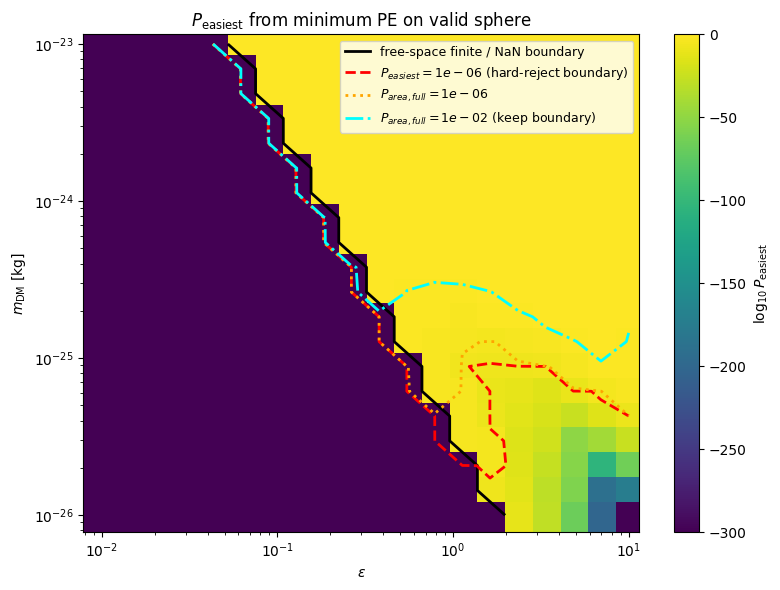

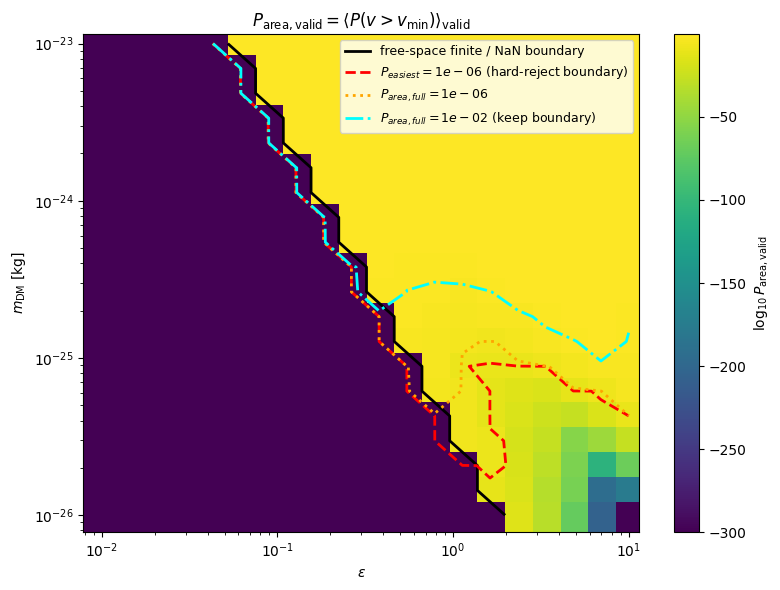

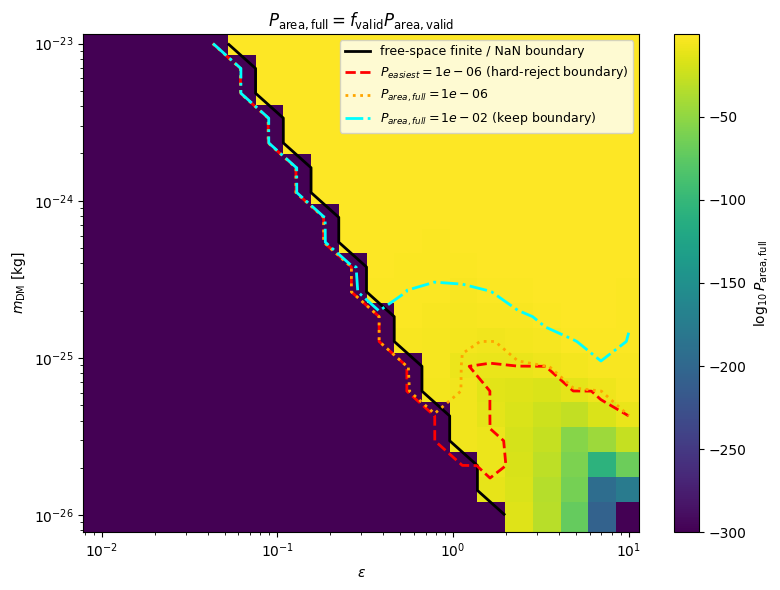

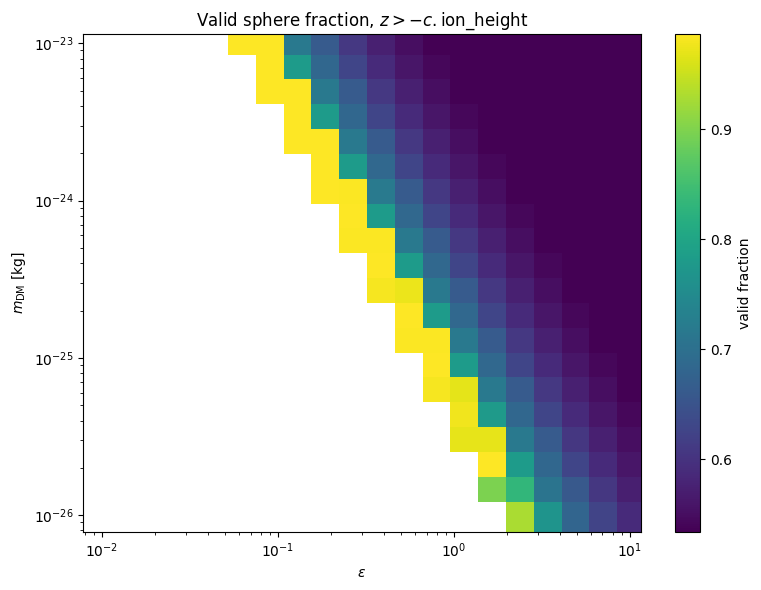

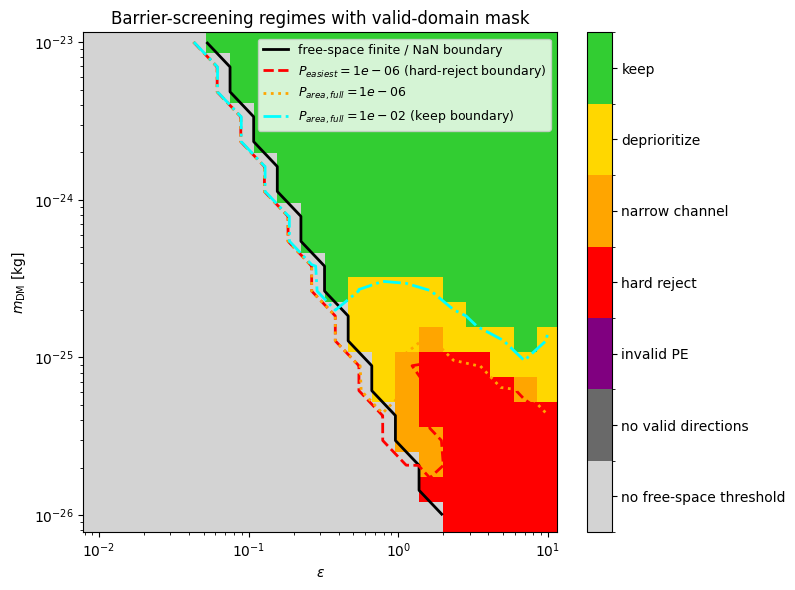

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import maxwell
from matplotlib.lines import Line2D
from matplotlib.colors import ListedColormap, BoundaryNorm

# -----------------------------
# Settings
# -----------------------------

T_dm = 300.0  # K
E_threshold = 1e-27
k_B = 1.380649e-23

p_hard = 1e-6
p_priority = 1e-2

n_sphere = 10000

# Since PE_list is absolute potential energy:
# If DM starts very far away and U(infinity) = 0, use this.
U_start = 0.0

# Potential validity domain.
# Your analytical electrode potential is valid only above the electrode plane.
try:
    z_min_valid = -c.ion_height
except NameError:
    z_min_valid = -70.0e-6

z_margin = 1.0e-6


def valid_xyz_mask(xyz):
    xyz = np.asarray(xyz, dtype=float)
    return xyz[..., 2] > (z_min_valid + z_margin)


def PE_on_valid_sphere(n, radius, m_dm, eps, component="total"):
    xyz_all = xyz_on_sphere(n, radius)
    valid_mask = valid_xyz_mask(xyz_all)
    xyz_valid = xyz_all[valid_mask]

    valid_fraction = np.mean(valid_mask)

    if xyz_valid.shape[0] == 0:
        return np.array([], dtype=float), valid_fraction, 0

    PE_list = np.array(
        [
            potential_energy(row, m_dm, eps, component)
            for row in xyz_valid
        ],
        dtype=float,
    )

    PE_list = PE_list[np.isfinite(PE_list)]

    return PE_list, valid_fraction, xyz_valid.shape[0]


# -----------------------------
# Parameter scan
# -----------------------------

m_dm_values = np.logspace(-26, -23, 20)
eps_values = np.logspace(-2, 1, 20)

# r_min_arr_um should be the 20 x 20 array from the previous scan.
# Values are in um. Convert to meters below.
r_min_arr_um = np.array([
    [np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, 80.339, 128.525, 191.405, 277.227, 396.576],
    [np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, 86.652, 103.708, 166.000, 218.235, 328.397, 477.806],
    [np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, 70.992, 122.777, 187.465, 274.376, 394.414, 579.788],
    [np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, 73.319, 73.419, 159.523, 213.372, 325.133, 475.469, 690.497],
    [np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, 72.127, 123.416, 187.850, 274.585, 394.477, 579.706, 828.805],
    [np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, 71.768, 73.664, 158.723, 212.708, 324.618, 475.018, 690.059, 998.627],
    [np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, 70.813, 122.618, 187.288, 274.153, 394.114, 579.376, 828.465, 998.652],
    [np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, 71.209, 71.255, 158.469, 212.509, 324.459, 474.867, 689.891, 998.419, 998.811],
    [np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, 70.838, 122.624, 187.278, 274.128, 394.071, 579.308, 828.366, 998.509, 998.952],
    [np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, 71.681, 72.857, 158.675, 212.657, 324.544, 474.908, 689.895, 998.389, 998.744, 999.255],
    [np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, 71.049, 122.740, 187.349, 274.171, 394.096, 579.320, 828.368, 998.504, 998.937, 999.561],
    [np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, 71.245, 71.264, 158.465, 212.494, 324.440, 474.843, 689.863, 998.388, 998.764, 999.305, 1000.084],
    [np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, 70.882, 122.658, 187.311, 274.165, 394.117, 579.367, 828.445, 998.618, 999.109, 999.816, 1000.834],
    [np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, 70.832, 71.177, 158.307, 212.399, 324.410, 474.867, 689.939, 998.520, 998.969, 999.614, 1000.544, 1001.884],
    [np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, 70.831, 122.646, 187.328, 274.210, 394.196, 579.491, 828.626, 998.879, 999.486, 1000.361, 1001.622, 1003.426],
    [np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, 70.911, 70.952, 158.381, 212.489, 324.526, 475.023, 690.155, 998.818, 999.395, 1000.227, 1001.425, 1003.154, 1005.642],
    [np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, 70.898, 122.720, 187.422, 274.335, 394.367, 579.727, 828.952, 999.336, 1000.139, 1001.296, 1002.964, 1005.374, 1008.835],
    [np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, 70.900, 70.976, 158.452, 212.605, 324.693, 475.263, 690.493, 999.289, 1000.074, 1001.205, 1002.836, 1005.181, 1008.568, 1013.449],
    [np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, 70.938, 122.791, 187.532, 274.500, 394.608, 580.072, 829.441, 1000.030, 1001.144, 1002.744, 1005.052, 1008.377, 1013.176, 1020.108],
    [np.nan, np.nan, np.nan, np.nan, np.nan, 70.929, 71.028, 158.561, 212.772, 324.945, 475.625, 691.003, 1000.000, 1001.098, 1002.682, 1004.960, 1008.246, 1012.987, 1019.836, 1029.748],
], dtype=float)

r_min_arr = r_min_arr_um * 1e-6
shape = (len(m_dm_values), len(eps_values))

# Main probability grids.
P_easiest_grid = np.full(shape, np.nan)
P_area_grid = np.full(shape, np.nan)          # same as P_area_full for compatibility
P_area_valid_grid = np.full(shape, np.nan)    # conditional on valid directions only
P_area_full_grid = np.full(shape, np.nan)     # valid_fraction * P_area_valid

# Geometry / validity grids.
valid_fraction_grid = np.full(shape, np.nan)
n_valid_grid = np.full(shape, np.nan)

# Fraction of valid/full directions that are above p_hard.
accessible_fraction_valid_grid = np.full(shape, np.nan)
accessible_fraction_full_grid = np.full(shape, np.nan)

v_min_easiest_grid = np.full(shape, np.nan)
v_min_median_grid = np.full(shape, np.nan)

PE_min_grid = np.full(shape, np.nan)
PE_median_grid = np.full(shape, np.nan)
PE_max_grid = np.full(shape, np.nan)

delta_PE_min_grid = np.full(shape, np.nan)
delta_PE_median_grid = np.full(shape, np.nan)
delta_PE_max_grid = np.full(shape, np.nan)

delta_PE_p90_grid = np.full(shape, np.nan)
delta_PE_p95_grid = np.full(shape, np.nan)
delta_PE_p99_grid = np.full(shape, np.nan)

status_grid = np.full(shape, "", dtype=object)

# -----------------------------
# Barrier accessibility scan
# -----------------------------

for i, m_dm in enumerate(m_dm_values):
    scale = np.sqrt(k_B * T_dm / m_dm)

    for j, eps in enumerate(eps_values):
        r_min_threshold = r_min_arr[i, j]

        if not np.isfinite(r_min_threshold) or r_min_threshold <= 0:
            P_easiest_grid[i, j] = 0.0
            P_area_grid[i, j] = 0.0
            P_area_valid_grid[i, j] = 0.0
            P_area_full_grid[i, j] = 0.0
            accessible_fraction_valid_grid[i, j] = 0.0
            accessible_fraction_full_grid[i, j] = 0.0
            v_min_easiest_grid[i, j] = np.inf
            v_min_median_grid[i, j] = np.inf
            valid_fraction_grid[i, j] = np.nan
            n_valid_grid[i, j] = 0
            status_grid[i, j] = "no_free_space_threshold"
            continue

        PE_list, valid_fraction, n_valid = PE_on_valid_sphere(
            n_sphere,
            r_min_threshold,
            m_dm,
            eps,
            component="total",
        )

        valid_fraction_grid[i, j] = valid_fraction
        n_valid_grid[i, j] = n_valid

        if n_valid == 0:
            P_easiest_grid[i, j] = 0.0
            P_area_grid[i, j] = 0.0
            P_area_valid_grid[i, j] = 0.0
            P_area_full_grid[i, j] = 0.0
            accessible_fraction_valid_grid[i, j] = 0.0
            accessible_fraction_full_grid[i, j] = 0.0
            v_min_easiest_grid[i, j] = np.inf
            v_min_median_grid[i, j] = np.inf
            status_grid[i, j] = "no_valid_directions"
            continue

        if PE_list.size == 0:
            P_easiest_grid[i, j] = 0.0
            P_area_grid[i, j] = 0.0
            P_area_valid_grid[i, j] = 0.0
            P_area_full_grid[i, j] = 0.0
            accessible_fraction_valid_grid[i, j] = 0.0
            accessible_fraction_full_grid[i, j] = 0.0
            v_min_easiest_grid[i, j] = np.inf
            v_min_median_grid[i, j] = np.inf
            status_grid[i, j] = "invalid_PE"
            continue

        # Since PE_list is absolute PE, subtract the starting potential.
        # For far-away start with U(infinity)=0, U_start = 0.
        delta_PE_list = PE_list - U_start

        # If a point is downhill relative to the start, it requires no kinetic
        # energy barrier to reach energetically.
        delta_PE_list = np.maximum(delta_PE_list, 0.0)

        PE_min_grid[i, j] = np.min(PE_list)
        PE_median_grid[i, j] = np.median(PE_list)
        PE_max_grid[i, j] = np.max(PE_list)

        delta_PE_min_grid[i, j] = np.min(delta_PE_list)
        delta_PE_median_grid[i, j] = np.median(delta_PE_list)
        delta_PE_max_grid[i, j] = np.max(delta_PE_list)

        delta_PE_p90_grid[i, j] = np.percentile(delta_PE_list, 90)
        delta_PE_p95_grid[i, j] = np.percentile(delta_PE_list, 95)
        delta_PE_p99_grid[i, j] = np.percentile(delta_PE_list, 99)

        # Easiest point on the valid part of the r_min_threshold sphere.
        v_min_easiest = np.sqrt(2.0 * delta_PE_min_grid[i, j] / m_dm)
        P_easiest = maxwell.sf(v_min_easiest, scale=scale)

        # Direction-dependent accessibility probability.
        v_min_all = np.sqrt(2.0 * delta_PE_list / m_dm)
        P_all = maxwell.sf(v_min_all, scale=scale)

        # Conditional on valid part of sphere.
        P_area_valid = np.mean(P_all)

        # Fraction of full 4pi sphere that is both valid and accessible.
        P_area_full = valid_fraction * P_area_valid

        accessible_fraction_valid = np.mean(P_all > p_hard)
        accessible_fraction_full = valid_fraction * accessible_fraction_valid

        v_min_easiest_grid[i, j] = v_min_easiest
        v_min_median_grid[i, j] = np.median(v_min_all)

        P_easiest_grid[i, j] = P_easiest
        P_area_valid_grid[i, j] = P_area_valid
        P_area_full_grid[i, j] = P_area_full

        # Keep old name compatible with old plotting code.
        # From now on, P_area_grid means full-sphere weighted probability.
        P_area_grid[i, j] = P_area_full

        accessible_fraction_valid_grid[i, j] = accessible_fraction_valid
        accessible_fraction_full_grid[i, j] = accessible_fraction_full

        # Regime classification uses P_area_full because that represents
        # actual full-sphere incoming flux suppression.
        if P_easiest < p_hard:
            status_grid[i, j] = "hard_reject"
        elif P_area_full < p_hard:
            status_grid[i, j] = "narrow_channel"
        elif P_area_full < p_priority:
            status_grid[i, j] = "deprioritize"
        else:
            status_grid[i, j] = "keep"

# -----------------------------
# Overall summary
# -----------------------------

unique_status, counts = np.unique(status_grid, return_counts=True)

print("Status counts:")
for s, c_count in zip(unique_status, counts):
    print(f"{s:25s}: {c_count}")

print()
print("Finite r_min entries:", np.sum(np.isfinite(r_min_arr)))
print("NaN r_min entries:", np.sum(~np.isfinite(r_min_arr)))

print()
print("Valid fraction over finite r_min entries:")
finite_mask = np.isfinite(r_min_arr) & (r_min_arr > 0)
print("min   :", np.nanmin(valid_fraction_grid[finite_mask]))
print("median:", np.nanmedian(valid_fraction_grid[finite_mask]))
print("max   :", np.nanmax(valid_fraction_grid[finite_mask]))

# -----------------------------
# Per-point summary dataframe
# -----------------------------

rows = []

for i, m_dm in enumerate(m_dm_values):
    for j, eps in enumerate(eps_values):
        rows.append({
            "m_dm_kg": m_dm,
            "eps": eps,
            "r_min_threshold_um": r_min_arr_um[i, j],
            "r_min_threshold_m": r_min_arr[i, j],
            "valid_fraction": valid_fraction_grid[i, j],
            "n_valid": n_valid_grid[i, j],
            "PE_min_J": PE_min_grid[i, j],
            "PE_median_J": PE_median_grid[i, j],
            "PE_max_J": PE_max_grid[i, j],
            "delta_PE_min_J": delta_PE_min_grid[i, j],
            "delta_PE_median_J": delta_PE_median_grid[i, j],
            "delta_PE_p90_J": delta_PE_p90_grid[i, j],
            "delta_PE_p95_J": delta_PE_p95_grid[i, j],
            "delta_PE_p99_J": delta_PE_p99_grid[i, j],
            "delta_PE_max_J": delta_PE_max_grid[i, j],
            "v_min_easiest_m_s": v_min_easiest_grid[i, j],
            "v_min_median_m_s": v_min_median_grid[i, j],
            "P_easiest_valid": P_easiest_grid[i, j],
            "P_area_valid": P_area_valid_grid[i, j],
            "P_area_full": P_area_full_grid[i, j],
            "accessible_fraction_valid": accessible_fraction_valid_grid[i, j],
            "accessible_fraction_full": accessible_fraction_full_grid[i, j],
            "status": status_grid[i, j],
        })

barrier_summary_df = pd.DataFrame(rows)

print()
print("Per-point barrier accessibility summary:")
print(barrier_summary_df.to_string(index=False))

# Optional: save results.
#barrier_summary_df.to_csv("barrier_summary_valid_domain.csv", index=False)

# -----------------------------
# Plot helper
# -----------------------------

def add_regime_contours(
    ax,
    EPS_grid,
    M_grid,
    r_min_arr,
    P_easiest_grid,
    P_area_grid,
    p_hard=1e-6,
    p_priority=1e-2,
):
    legend_handles = []

    # ------------------------------------------------------------
    # 1. Free-space finite / NaN boundary
    # ------------------------------------------------------------
    finite_mask = np.isfinite(r_min_arr) & (r_min_arr > 0)

    if np.any(finite_mask) and np.any(~finite_mask):
        ax.contour(
            EPS_grid,
            M_grid,
            finite_mask.astype(float),
            levels=[0.5],
            colors="black",
            linewidths=2,
            linestyles="-",
        )
        legend_handles.append(
            Line2D(
                [0],
                [0],
                color="black",
                lw=2,
                linestyle="-",
                label="free-space finite / NaN boundary",
            )
        )

    # ------------------------------------------------------------
    # 2. Hard reject boundary: P_easiest = p_hard
    # ------------------------------------------------------------
    P_easiest_safe = np.array(P_easiest_grid, dtype=float)

    if np.any(np.isfinite(P_easiest_safe)):
        try:
            ax.contour(
                EPS_grid,
                M_grid,
                P_easiest_safe,
                levels=[p_hard],
                colors="red",
                linewidths=2,
                linestyles="--",
            )
            legend_handles.append(
                Line2D(
                    [0],
                    [0],
                    color="red",
                    lw=2,
                    linestyle="--",
                    label=rf"$P_{{easiest}}={p_hard:.0e}$ (hard-reject boundary)",
                )
            )
        except ValueError:
            pass

    # ------------------------------------------------------------
    # 3. Narrow-channel boundary: P_area = p_hard
    # ------------------------------------------------------------
    P_area_safe = np.array(P_area_grid, dtype=float)

    if np.any(np.isfinite(P_area_safe)):
        try:
            ax.contour(
                EPS_grid,
                M_grid,
                P_area_safe,
                levels=[p_hard],
                colors="orange",
                linewidths=2,
                linestyles=":",
            )
            legend_handles.append(
                Line2D(
                    [0],
                    [0],
                    color="orange",
                    lw=2,
                    linestyle=":",
                    label=rf"$P_{{area,full}}={p_hard:.0e}$",
                )
            )
        except ValueError:
            pass

        # --------------------------------------------------------
        # 4. Keep / deprioritize boundary: P_area = p_priority
        # --------------------------------------------------------
        try:
            ax.contour(
                EPS_grid,
                M_grid,
                P_area_safe,
                levels=[p_priority],
                colors="cyan",
                linewidths=2,
                linestyles="-.",
            )
            legend_handles.append(
                Line2D(
                    [0],
                    [0],
                    color="cyan",
                    lw=2,
                    linestyle="-.",
                    label=rf"$P_{{area,full}}={p_priority:.0e}$ (keep boundary)",
                )
            )
        except ValueError:
            pass

    if legend_handles:
        ax.legend(handles=legend_handles, loc="best", fontsize=9)


M_grid, EPS_grid = np.meshgrid(m_dm_values, eps_values, indexing="ij")

# -----------------------------
# Plot 1: P_easiest_valid
# -----------------------------

plot_quantity = P_easiest_grid
plot_title = r"$P_{\rm easiest}$ from minimum PE on valid sphere"

plot_quantity_safe = np.maximum(plot_quantity, 1e-300)

fig, ax = plt.subplots(figsize=(8, 6))

pcm = ax.pcolormesh(
    EPS_grid,
    M_grid,
    np.log10(plot_quantity_safe),
    shading="auto",
)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(r"$\epsilon$")
ax.set_ylabel(r"$m_{\rm DM}$ [kg]")
ax.set_title(plot_title)

cbar = fig.colorbar(pcm, ax=ax)
cbar.set_label(r"$\log_{10} P_{\rm easiest}$")

add_regime_contours(
    ax=ax,
    EPS_grid=EPS_grid,
    M_grid=M_grid,
    r_min_arr=r_min_arr,
    P_easiest_grid=P_easiest_grid,
    P_area_grid=P_area_full_grid,
    p_hard=p_hard,
    p_priority=p_priority,
)

plt.tight_layout()
plt.show()

# -----------------------------
# Plot 2: P_area_valid
# -----------------------------

plot_quantity = P_area_valid_grid
plot_quantity_safe = np.maximum(plot_quantity, 1e-300)

fig, ax = plt.subplots(figsize=(8, 6))

pcm = ax.pcolormesh(
    EPS_grid,
    M_grid,
    np.log10(plot_quantity_safe),
    shading="auto",
)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(r"$\epsilon$")
ax.set_ylabel(r"$m_{\rm DM}$ [kg]")
ax.set_title(r"$P_{\rm area,valid}=\langle P(v>v_{\min})\rangle_{\rm valid}$")

cbar = fig.colorbar(pcm, ax=ax)
cbar.set_label(r"$\log_{10} P_{\rm area,valid}$")

add_regime_contours(
    ax=ax,
    EPS_grid=EPS_grid,
    M_grid=M_grid,
    r_min_arr=r_min_arr,
    P_easiest_grid=P_easiest_grid,
    P_area_grid=P_area_full_grid,
    p_hard=p_hard,
    p_priority=p_priority,
)

plt.tight_layout()
plt.show()

# -----------------------------
# Plot 3: P_area_full
# -----------------------------

plot_quantity = P_area_full_grid
plot_quantity_safe = np.maximum(plot_quantity, 1e-300)

fig, ax = plt.subplots(figsize=(8, 6))

pcm = ax.pcolormesh(
    EPS_grid,
    M_grid,
    np.log10(plot_quantity_safe),
    shading="auto",
)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(r"$\epsilon$")
ax.set_ylabel(r"$m_{\rm DM}$ [kg]")
ax.set_title(r"$P_{\rm area,full}=f_{\rm valid}P_{\rm area,valid}$")

cbar = fig.colorbar(pcm, ax=ax)
cbar.set_label(r"$\log_{10} P_{\rm area,full}$")

add_regime_contours(
    ax=ax,
    EPS_grid=EPS_grid,
    M_grid=M_grid,
    r_min_arr=r_min_arr,
    P_easiest_grid=P_easiest_grid,
    P_area_grid=P_area_full_grid,
    p_hard=p_hard,
    p_priority=p_priority,
)

plt.tight_layout()
plt.show()

# -----------------------------
# Plot 4: Valid fraction
# -----------------------------

fig, ax = plt.subplots(figsize=(8, 6))

pcm = ax.pcolormesh(
    EPS_grid,
    M_grid,
    valid_fraction_grid,
    shading="auto",
)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(r"$\epsilon$")
ax.set_ylabel(r"$m_{\rm DM}$ [kg]")
ax.set_title(r"Valid sphere fraction, $z>-c.\mathrm{ion\_height}$")

cbar = fig.colorbar(pcm, ax=ax)
cbar.set_label("valid fraction")

plt.tight_layout()
plt.show()

# -----------------------------
# Plot 5: Regime map
# -----------------------------

status_order = [
    "no_free_space_threshold",
    "no_valid_directions",
    "invalid_PE",
    "hard_reject",
    "narrow_channel",
    "deprioritize",
    "keep",
]

status_to_code = {name: idx for idx, name in enumerate(status_order)}

status_code = np.full(status_grid.shape, -1, dtype=int)

for name, code in status_to_code.items():
    status_code[status_grid == name] = code

cmap = ListedColormap([
    "lightgray",    # no_free_space_threshold
    "dimgray",      # no_valid_directions
    "purple",       # invalid_PE
    "red",          # hard_reject
    "orange",       # narrow_channel
    "gold",         # deprioritize
    "limegreen",    # keep
])

norm = BoundaryNorm(
    np.arange(-0.5, len(status_order) + 0.5, 1.0),
    cmap.N,
)

fig, ax = plt.subplots(figsize=(8, 6))

pcm = ax.pcolormesh(
    EPS_grid,
    M_grid,
    status_code,
    shading="auto",
    cmap=cmap,
    norm=norm,
)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(r"$\epsilon$")
ax.set_ylabel(r"$m_{\rm DM}$ [kg]")
ax.set_title("Barrier-screening regimes with valid-domain mask")

cbar = fig.colorbar(
    pcm,
    ax=ax,
    ticks=list(range(len(status_order))),
)

cbar.ax.set_yticklabels([
    "no free-space threshold",
    "no valid directions",
    "invalid PE",
    "hard reject",
    "narrow channel",
    "deprioritize",
    "keep",
])

add_regime_contours(
    ax=ax,
    EPS_grid=EPS_grid,
    M_grid=M_grid,
    r_min_arr=r_min_arr,
    P_easiest_grid=P_easiest_grid,
    P_area_grid=P_area_full_grid,
    p_hard=p_hard,
    p_priority=p_priority,
)

plt.tight_layout()
plt.show()

# Potential Landscape Test

In [13]:
m_dm = 2.636651e-25
eps = 2.335721

Representative MB speeds:
q= 0.010, v=   42.472423 m/s
q= 0.050, v=   74.345117 m/s
q= 0.100, v=   95.812357 m/s
q= 0.500, v=  192.788408 m/s
q= 0.900, v=  313.374890 m/s
q= 0.950, v=  350.374810 m/s
q= 0.990, v=  422.158603 m/s
q= 0.999, v=  505.498047 m/s
Evaluating sphere diagnostics at r = 100 um
r = 100 um, valid sphere fraction = 0.846
Evaluating sphere diagnostics at r = 150 um
r = 150 um, valid sphere fraction = 0.730
Evaluating sphere diagnostics at r = 200 um
r = 200 um, valid sphere fraction = 0.672
Evaluating sphere diagnostics at r = 300 um
r = 300 um, valid sphere fraction = 0.616
Evaluating sphere diagnostics at r = 500 um
r = 500 um, valid sphere fraction = 0.570
Evaluating sphere diagnostics at r = 750 um
r = 750 um, valid sphere fraction = 0.546
Evaluating sphere diagnostics at r = 1000 um
r = 1000 um, valid sphere fraction = 0.534
Evaluating sphere diagnostics at r = 2000 um
r = 2000 um, valid sphere fraction = 0.518
Evaluating sphere diagnostics at r = 5000 um
r = 5

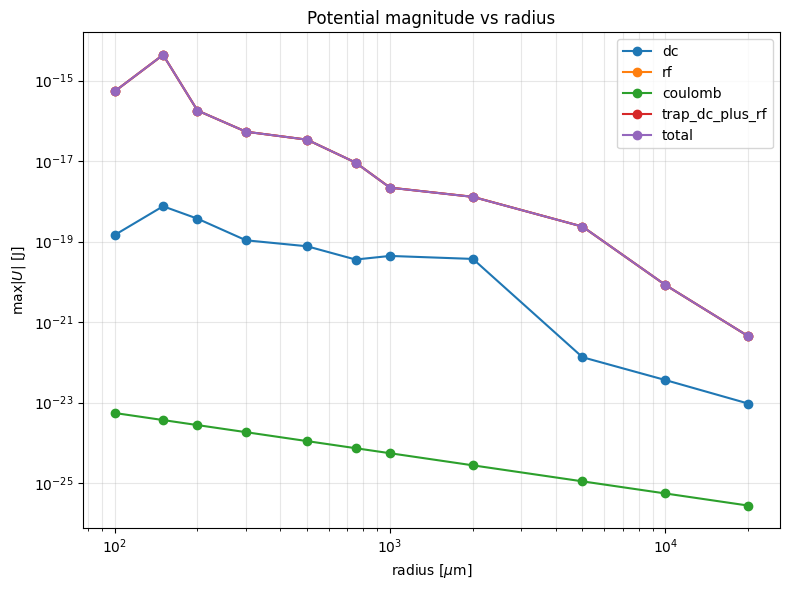

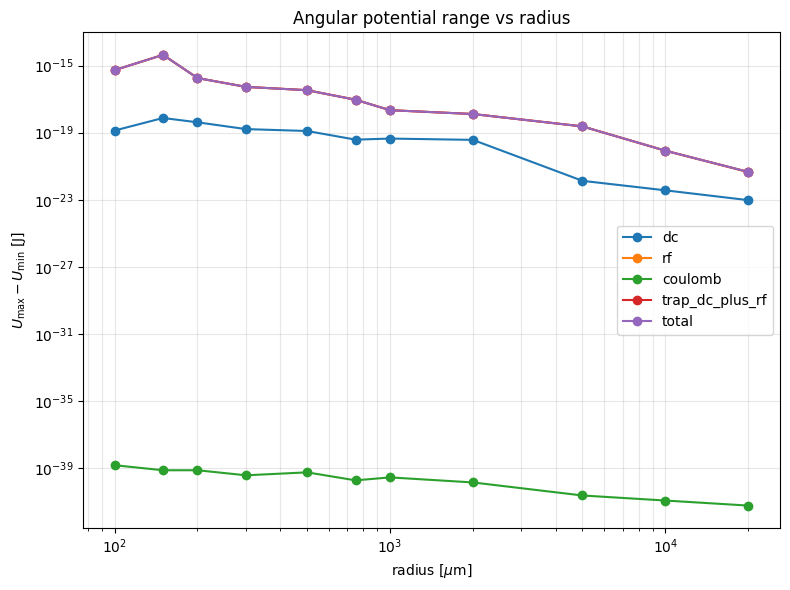

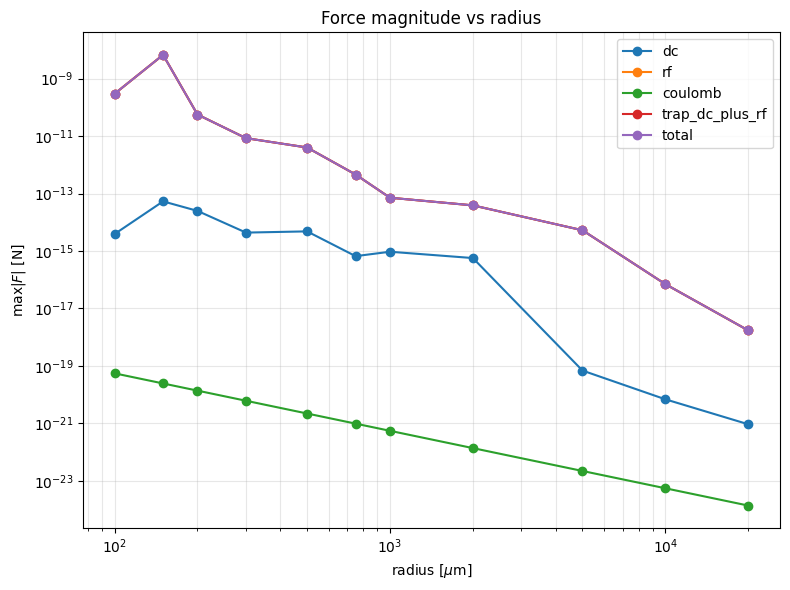

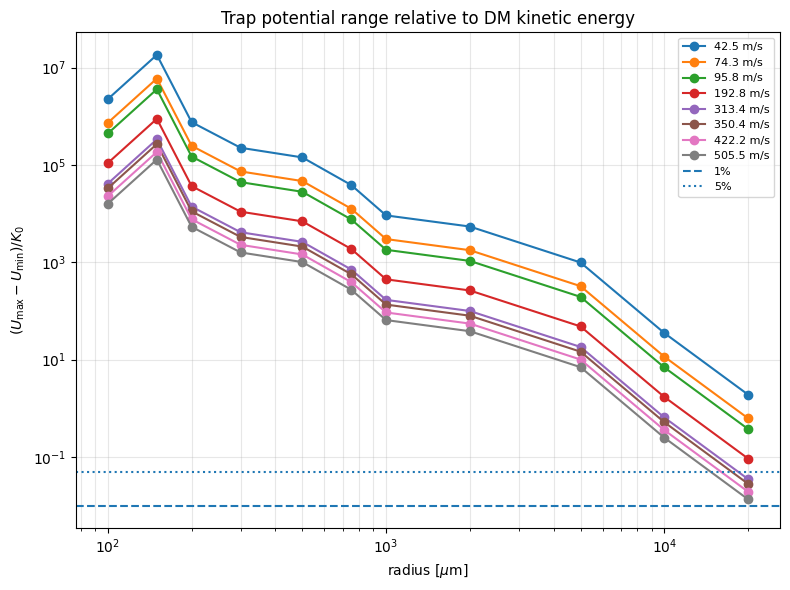

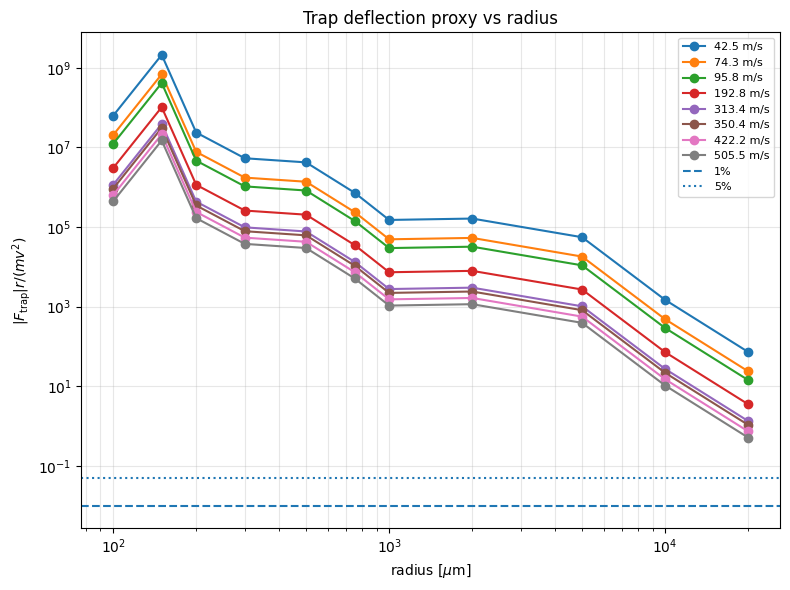

Evaluating 2D potential map in xz plane


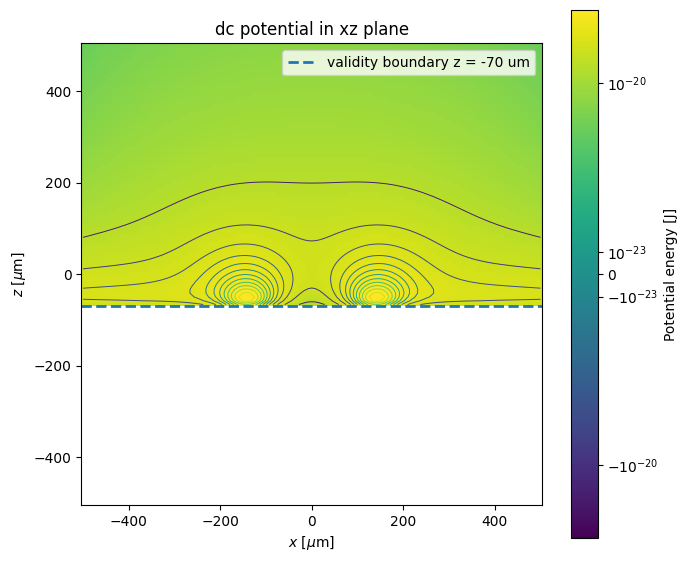

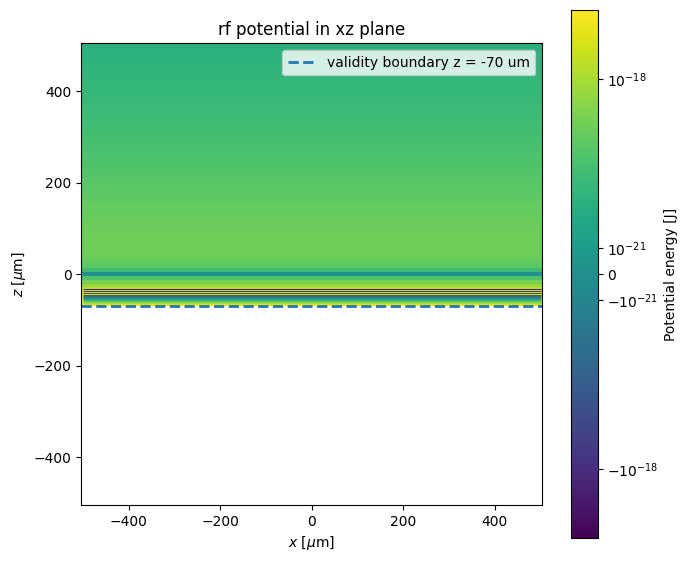

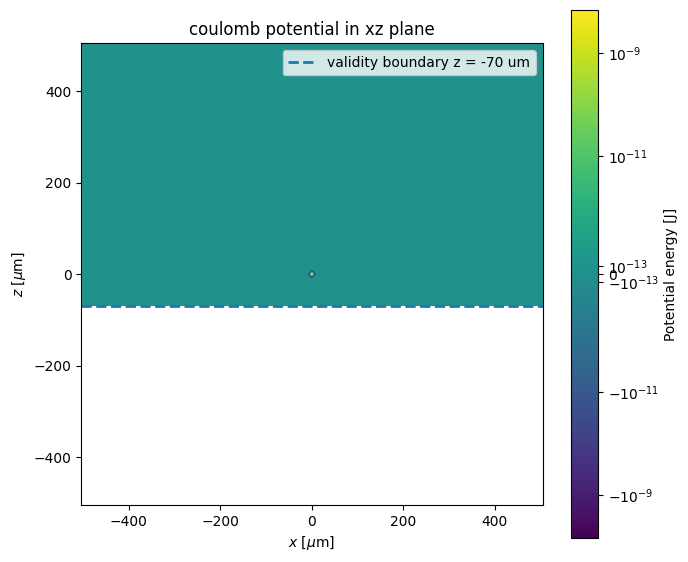

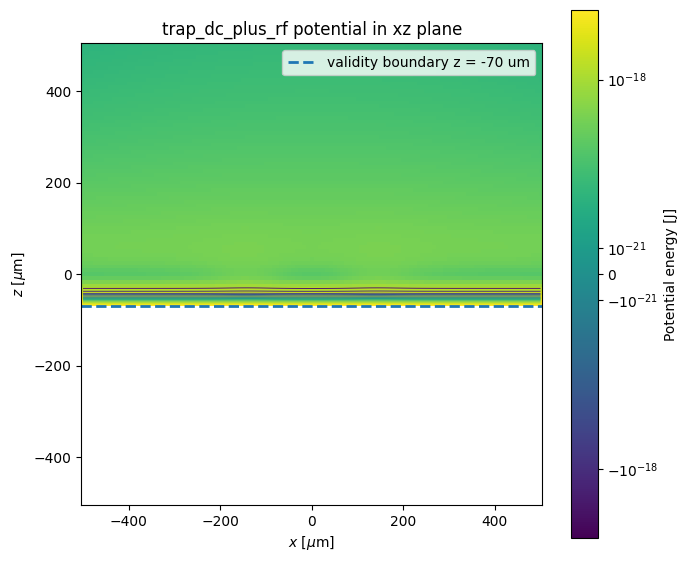

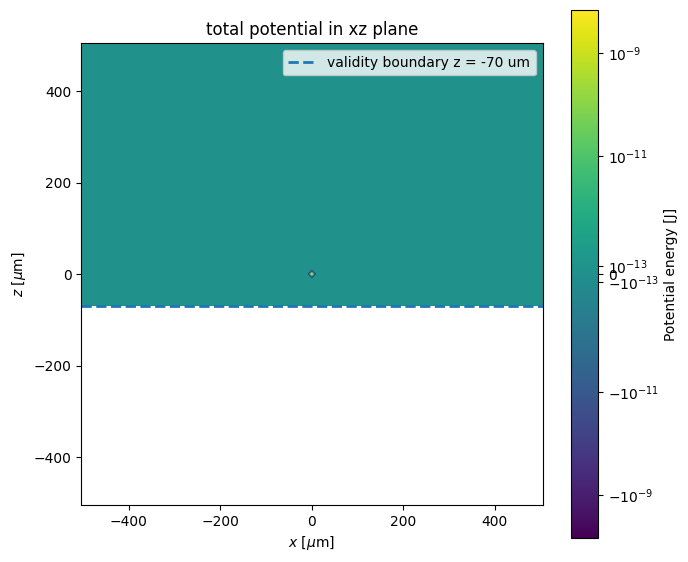

Evaluating 2D force map in xz plane


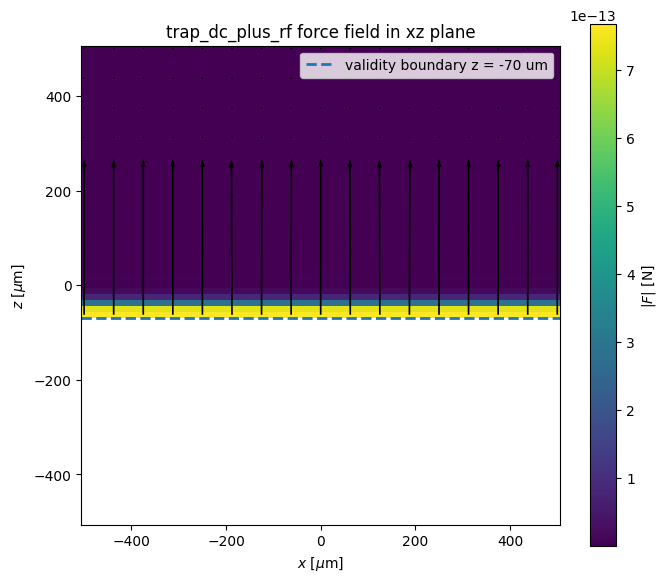

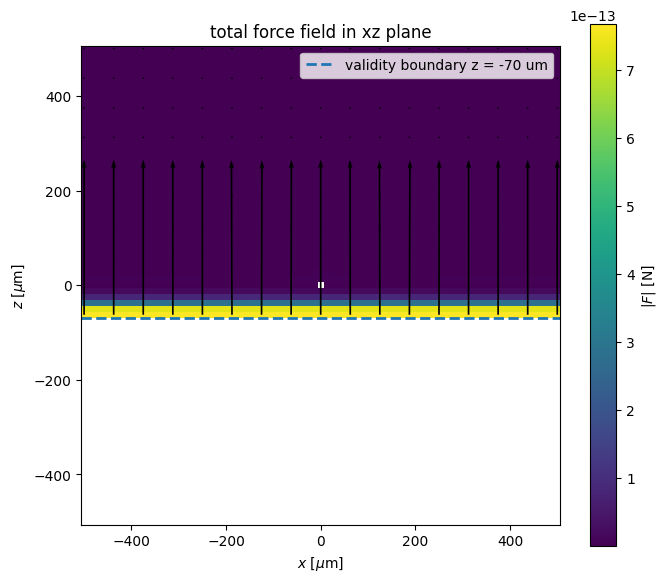

Evaluating 2D potential map in xy plane


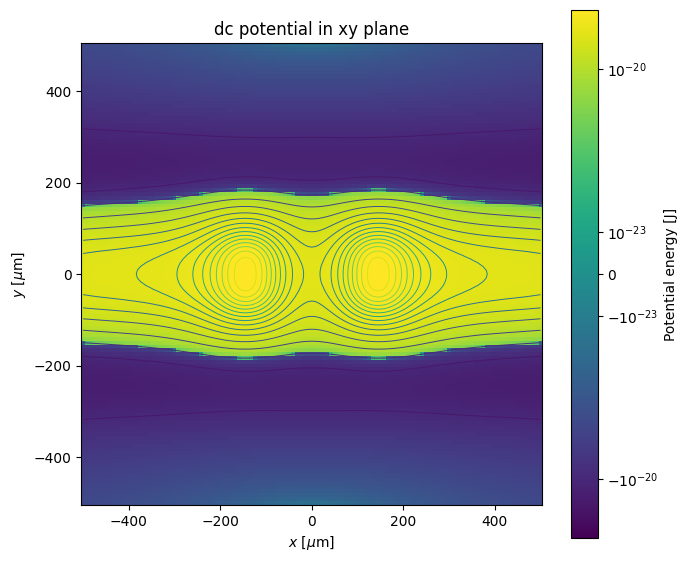

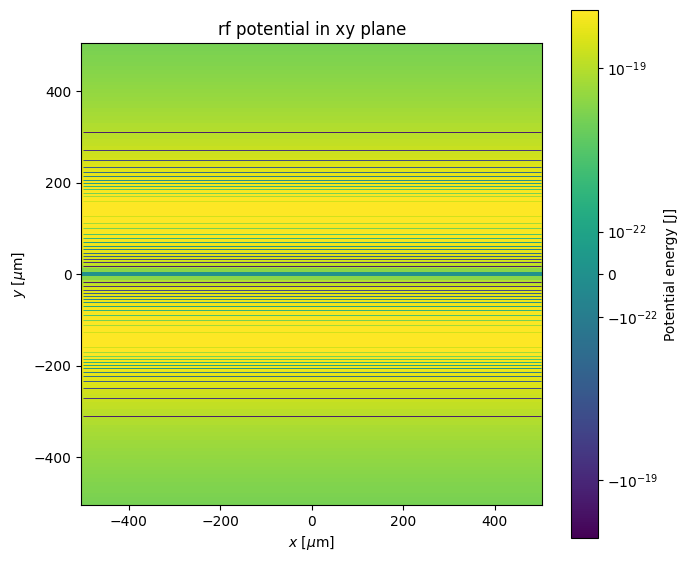

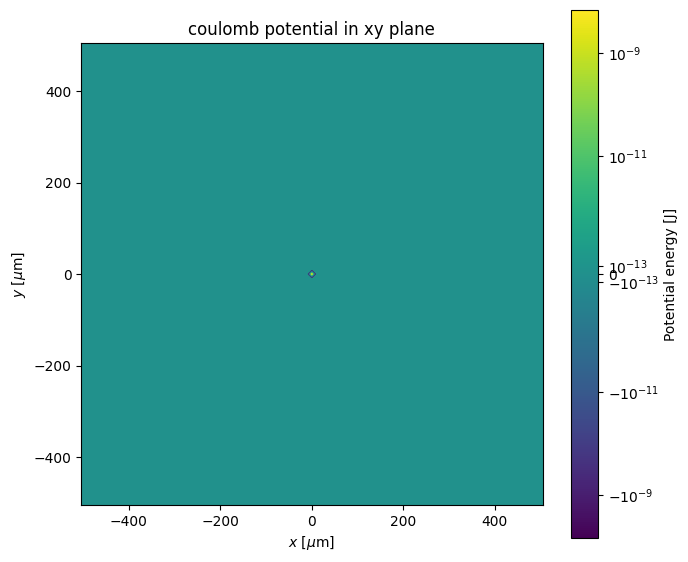

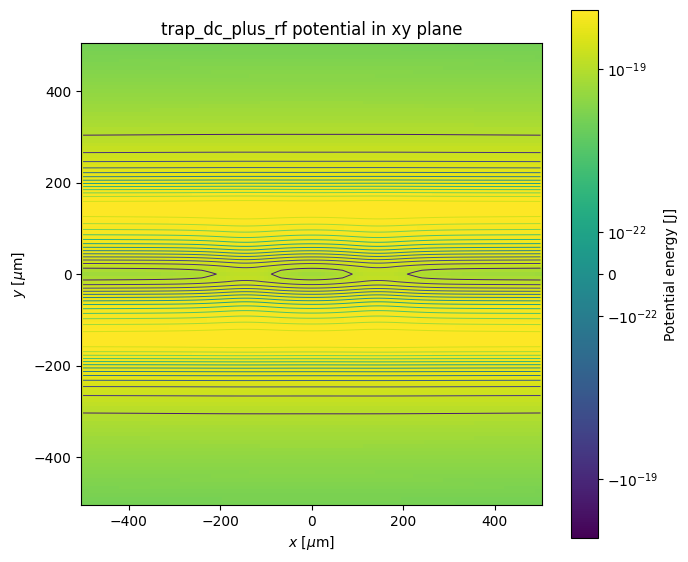

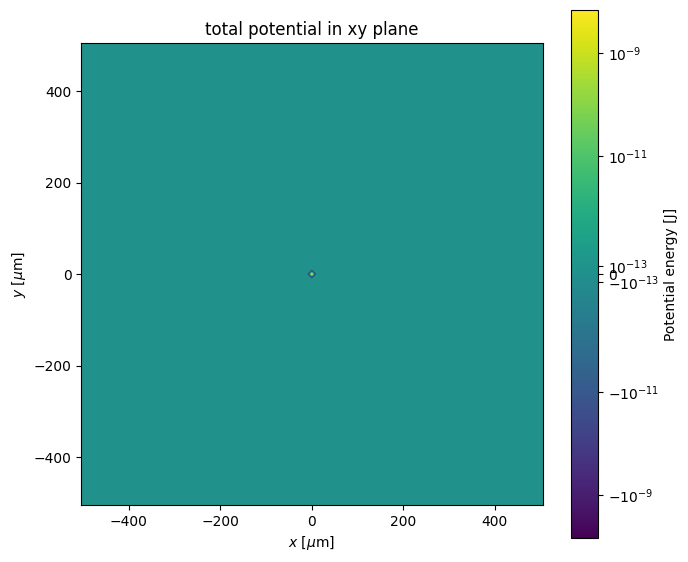

Evaluating 2D force map in xy plane


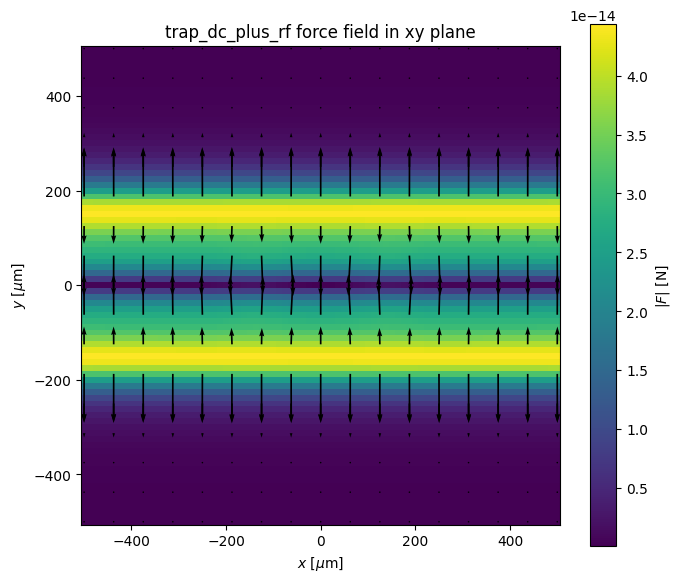

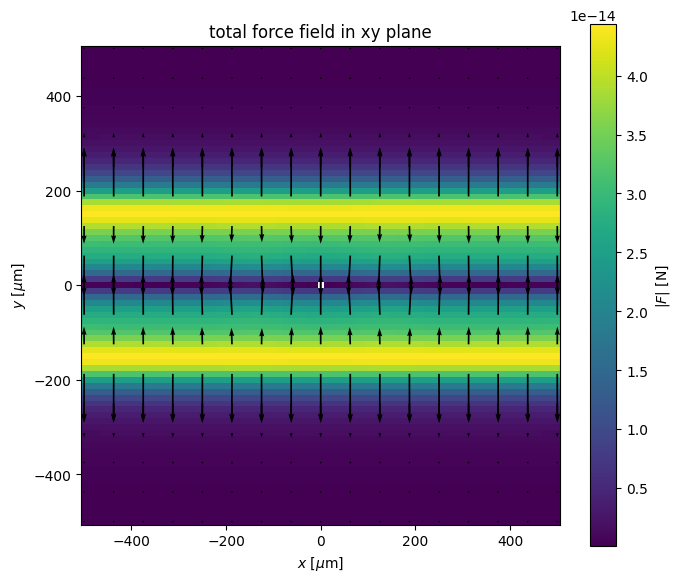

Evaluating 2D potential map in yz plane


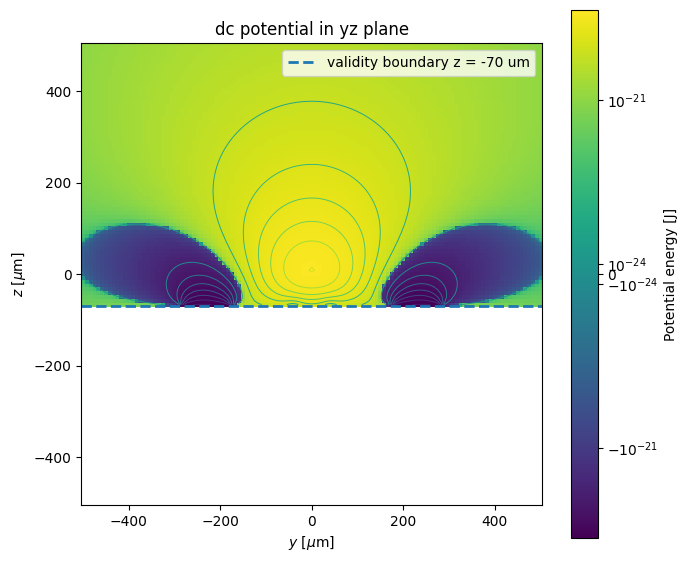

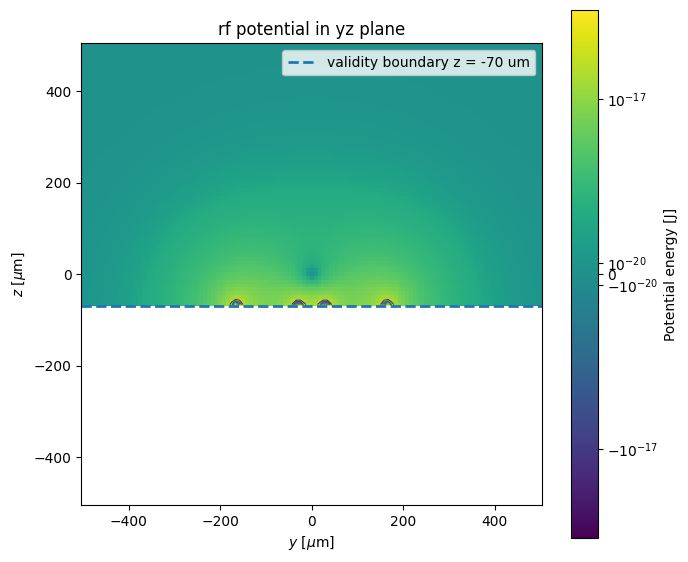

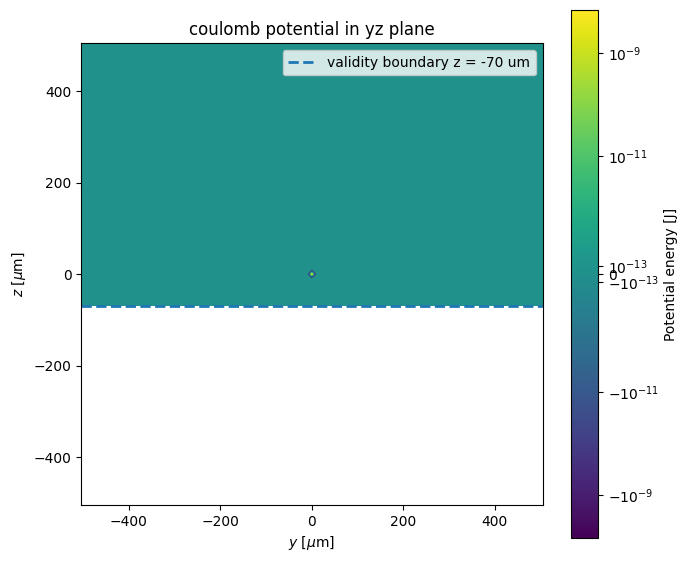

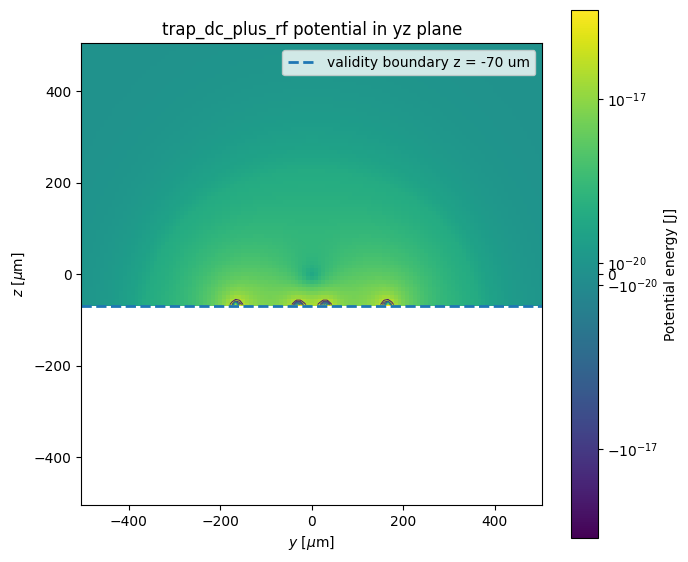

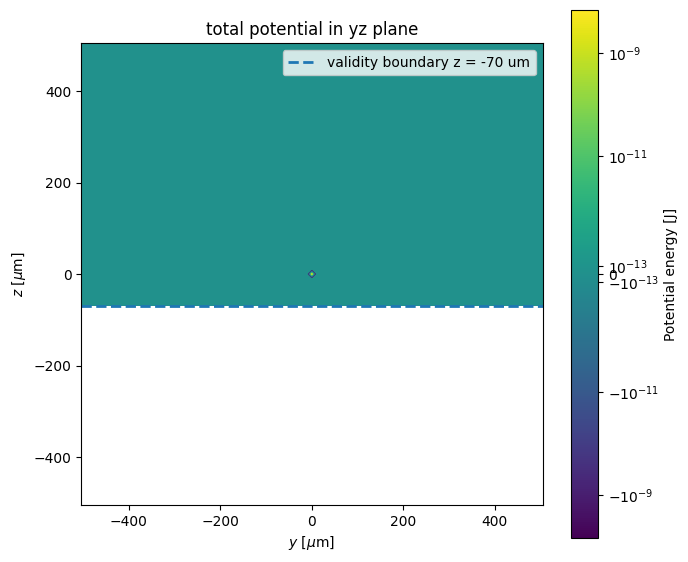

Evaluating 2D force map in yz plane


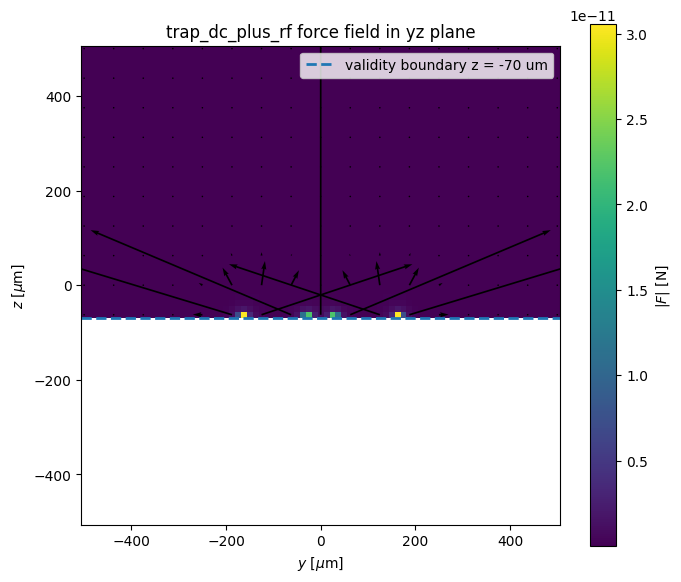

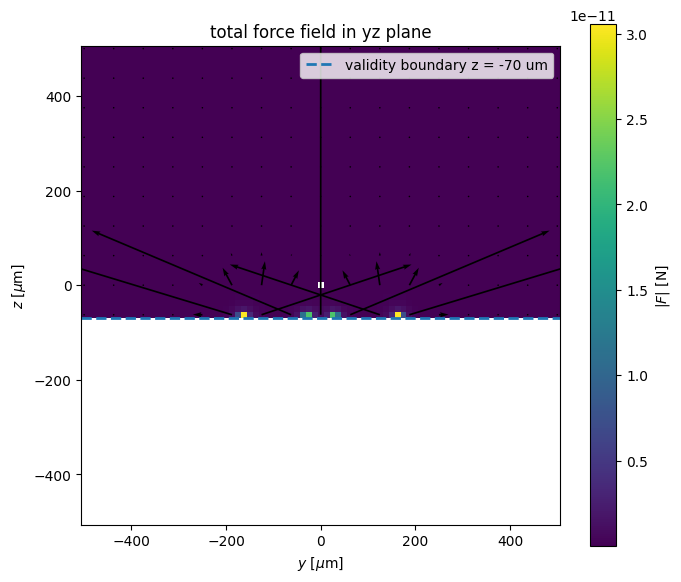

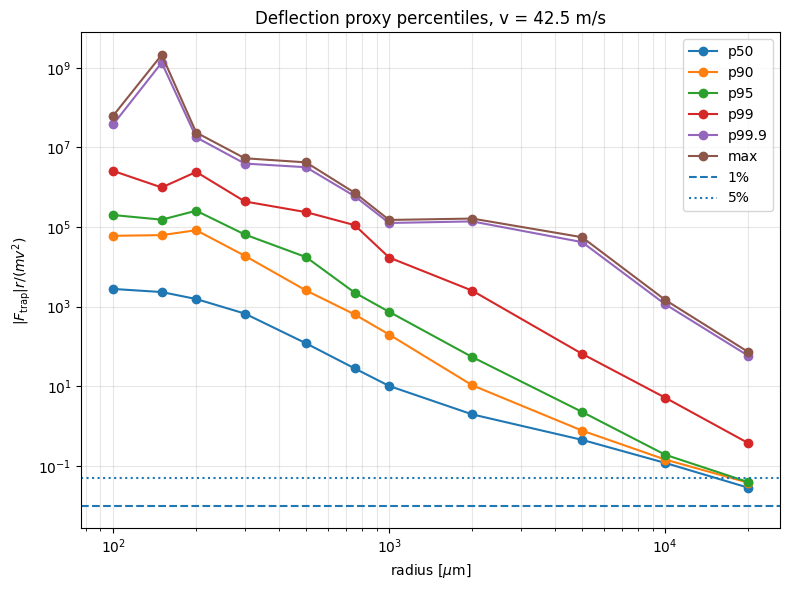

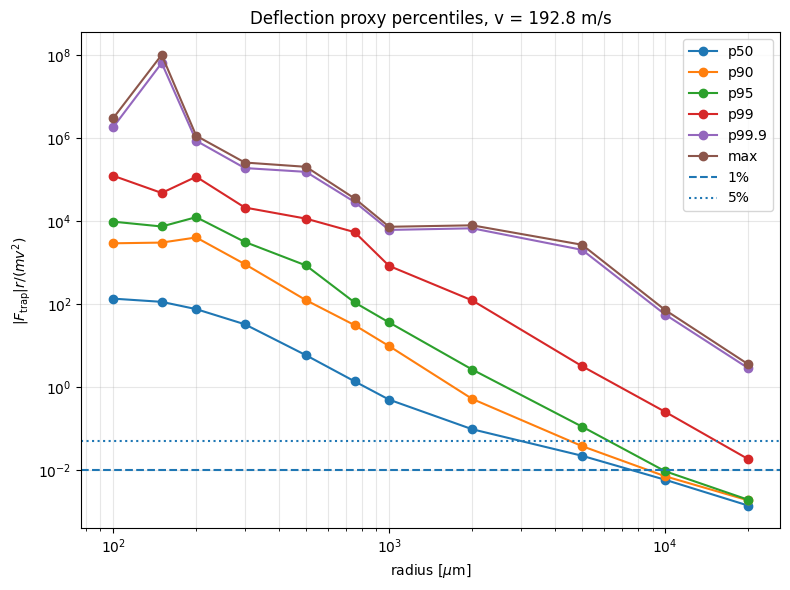

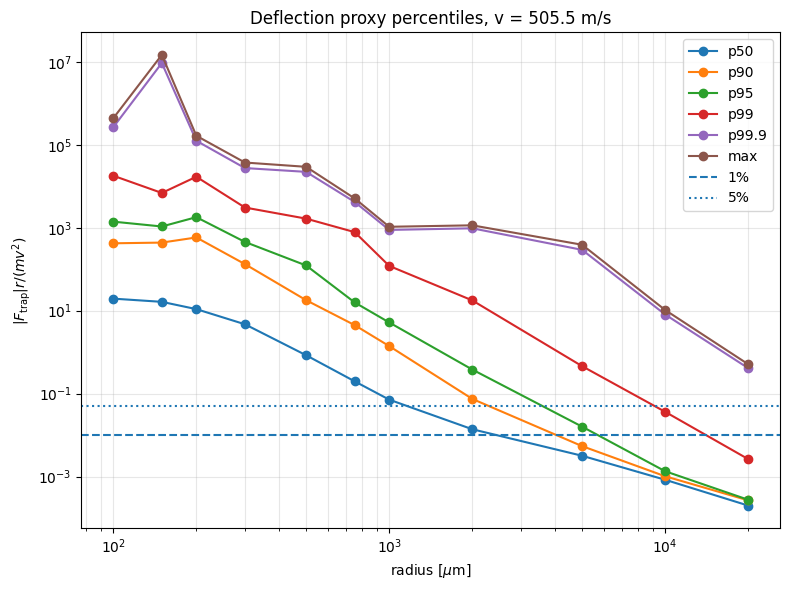

In [92]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import SymLogNorm
from scipy.stats import maxwell


# ============================================================
# User settings
# ============================================================

m_dm = 2.636651e-25
eps = 2.335721
T_dm = 300.0

# Edit these if your potential_energy(..., total) function uses different labels.
TERM_NAMES = {
    "dc": "dc",
    "rf": "pseudo_rf",
    "coulomb": "coulomb",
}

def add_scalar_percentiles(row_dict, prefix, arr):
    arr = np.asarray(arr, dtype=float)
    arr = arr[np.isfinite(arr)]

    if arr.size == 0:
        for p in ["p50", "p90", "p95", "p99", "p999", "max"]:
            row_dict[f"{prefix}_{p}"] = np.nan
        return row_dict

    row_dict[f"{prefix}_p50"] = np.percentile(arr, 50)
    row_dict[f"{prefix}_p90"] = np.percentile(arr, 90)
    row_dict[f"{prefix}_p95"] = np.percentile(arr, 95)
    row_dict[f"{prefix}_p99"] = np.percentile(arr, 99)
    row_dict[f"{prefix}_p999"] = np.percentile(arr, 99.9)
    row_dict[f"{prefix}_max"] = np.max(arr)

    return row_dict

# Radial diagnostic radii.
radii_um = np.array([
    100.0,
    150.0,
    200.0,
    300.0,
    500.0,
    750.0,
    1000.0,
    2000.0,
    5000.0,
    10000.0,
    20000.0,
])

radii_m = radii_um * 1e-6

# Use fewer sphere points first because force evaluation can be expensive.
n_sphere = 500

# Speeds to compare against the trap potential/force.
speed_quantiles = np.array([
    0.01,
    0.05,
    0.10,
    0.50,
    0.90,
    0.95,
    0.99,
    0.999,
])

speed_cases = deterministic_MB_speeds(T_dm, m_dm, speed_quantiles)

print("Representative MB speeds:")
for q, v in zip(speed_quantiles, speed_cases):
    print(f"q={q:6.3f}, v={v:12.6f} m/s")


# ============================================================
# Robust wrappers around your functions
# ============================================================

def as_clean_1d(values):
    arr = np.asarray(values, dtype=float).reshape(-1)
    return arr[np.isfinite(arr)]


def as_force_array(values):
    arr = np.asarray(values, dtype=float)
    arr = np.squeeze(arr)

    if arr.ndim == 1:
        if arr.size == 3:
            arr = arr.reshape(1, 3)
        else:
            arr = arr.reshape(-1, 3)

    if arr.ndim > 2:
        arr = arr.reshape(arr.shape[0], -1)

    if arr.shape[-1] != 3:
        arr = arr.reshape(-1, 3)

    good = np.all(np.isfinite(arr), axis=1)
    return arr[good]


def PE_component_on_sphere(n, radius, m_dm, eps, component):
    term = TERM_NAMES[component]
    xyz = xyz_on_valid_sphere(n, radius)

    values = []
    for row in xyz:
        values.append(potential_energy(row, m_dm, eps, term))

    return as_clean_1d(values)


def F_component_on_sphere(n, radius, m_dm, eps, component):
    term = TERM_NAMES[component]
    xyz = xyz_on_valid_sphere(n, radius)

    values = []
    for row in xyz:
        values.append(force([row], m_dm, eps, term))

    return as_force_array(values)


def PE_point(xyz, m_dm, eps, component):
    term = TERM_NAMES[component]
    return float(potential_energy(np.asarray(xyz, dtype=float), m_dm, eps, term))


def F_point(xyz, m_dm, eps, component):
    term = TERM_NAMES[component]
    raw = force([np.asarray(xyz, dtype=float)], m_dm, eps, term)
    arr = np.asarray(raw, dtype=float).reshape(-1, 3)
    return arr[0]


def kinetic_energy(m_dm, speed):
    return 0.5 * m_dm * speed**2


# ============================================================
# 1. Radial potential and force diagnostics on spheres
# ============================================================

potential_rows = []
force_rows = []
ratio_rows = []

for r_um, r in zip(radii_um, radii_m):
    print(f"Evaluating sphere diagnostics at r = {r_um:g} um")

    valid_fraction = valid_fraction_on_sphere(n_sphere, r)
    print(f"r = {r_um:g} um, valid sphere fraction = {valid_fraction:.3f}")
    U_dc = PE_component_on_sphere(n_sphere, r, m_dm, eps, "dc")
    U_rf = PE_component_on_sphere(n_sphere, r, m_dm, eps, "rf")
    U_coulomb = PE_component_on_sphere(n_sphere, r, m_dm, eps, "coulomb")

    # Use common length just in case one component drops invalid points.
    n_good_U = min(len(U_dc), len(U_rf), len(U_coulomb))
    U_dc = U_dc[:n_good_U]
    U_rf = U_rf[:n_good_U]
    U_coulomb = U_coulomb[:n_good_U]

    U_trap = U_dc + U_rf
    U_total = U_trap + U_coulomb

    potential_terms = {
        "dc": U_dc,
        "rf": U_rf,
        "coulomb": U_coulomb,
        "trap_dc_plus_rf": U_trap,
        "total": U_total,
    }

    for name, U in potential_terms.items():
        row = {
            "r_um": r_um,
            "valid_fraction": valid_fraction,
            "term": name,
            "U_min_J": np.nanmin(U),
            "U_median_J": np.nanmedian(U),
            "U_max_J": np.nanmax(U),
            "U_range_J": np.nanmax(U) - np.nanmin(U),
            "U_abs_max_J": np.nanmax(np.abs(U)),
        }

        row = add_scalar_percentiles(row, "U_J", U)
        potential_rows.append(row)

    F_dc = F_component_on_sphere(n_sphere, r, m_dm, eps, "dc")
    F_rf = F_component_on_sphere(n_sphere, r, m_dm, eps, "rf")
    F_coulomb = F_component_on_sphere(n_sphere, r, m_dm, eps, "coulomb")

    n_good_F = min(len(F_dc), len(F_rf), len(F_coulomb))
    F_dc = F_dc[:n_good_F]
    F_rf = F_rf[:n_good_F]
    F_coulomb = F_coulomb[:n_good_F]

    F_trap = F_dc + F_rf
    F_total = F_trap + F_coulomb

    force_terms = {
        "dc": F_dc,
        "rf": F_rf,
        "coulomb": F_coulomb,
        "trap_dc_plus_rf": F_trap,
        "total": F_total,
    }

    for name, F in force_terms.items():
        F_mag = np.linalg.norm(F, axis=1)

        row = {
            "r_um": r_um,
            "valid_fraction": valid_fraction,
            "term": name,
            "F_min_N": np.nanmin(F_mag),
            "F_median_N": np.nanmedian(F_mag),
            "F_max_N": np.nanmax(F_mag),
        }

        row = add_scalar_percentiles(row, "F_N", F_mag)
        force_rows.append(row)

    U_trap_range = np.nanmax(U_trap) - np.nanmin(U_trap)
    U_trap_abs_max = np.nanmax(np.abs(U_trap))
    F_trap_mag = np.linalg.norm(F_trap, axis=1)
    F_trap_max = np.nanmax(F_trap_mag)
    F_trap_median = np.nanmedian(F_trap_mag)

    for speed in speed_cases:
        K0 = kinetic_energy(m_dm, speed)
        deflection_proxy = F_trap_mag * r / (m_dm * speed**2)

        row = {
            "r_um": r_um,
            "valid_fraction": valid_fraction,
            "speed_m_s": speed,
            "K0_J": K0,
            "U_trap_range_over_K0": U_trap_range / K0,
            "U_trap_absmax_over_K0": U_trap_abs_max / K0,
            "deflection_proxy_max": np.nanmax(deflection_proxy),
            "deflection_proxy_median": np.nanmedian(deflection_proxy),
        }

        row = add_scalar_percentiles(row, "deflection_proxy", deflection_proxy)
        ratio_rows.append(row)


potential_stats_df = pd.DataFrame(potential_rows)
force_stats_df = pd.DataFrame(force_rows)
ratio_stats_df = pd.DataFrame(ratio_rows)

print()
print("Potential radial stats:")
print(potential_stats_df.to_string(index=False))

print()
print("Force radial stats:")
print(force_stats_df.to_string(index=False))

print()
print("Trap ratio stats:")
print(ratio_stats_df.to_string(index=False))


# ============================================================
# 2. Radial plots
# ============================================================

def plot_potential_absmax():
    fig, ax = plt.subplots(figsize=(8, 6))

    for term in ["dc", "rf", "coulomb", "trap_dc_plus_rf", "total"]:
        sub = potential_stats_df[potential_stats_df["term"] == term]
        ax.plot(
            sub["r_um"],
            sub["U_abs_max_J"],
            marker="o",
            label=term,
        )

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel(r"radius [$\mu$m]")
    ax.set_ylabel(r"$\max |U|$ [J]")
    ax.set_title("Potential magnitude vs radius")
    ax.legend()
    ax.grid(True, which="both", alpha=0.3)
    plt.tight_layout()
    plt.show()


def plot_potential_range():
    fig, ax = plt.subplots(figsize=(8, 6))

    for term in ["dc", "rf", "coulomb", "trap_dc_plus_rf", "total"]:
        sub = potential_stats_df[potential_stats_df["term"] == term]
        ax.plot(
            sub["r_um"],
            sub["U_range_J"],
            marker="o",
            label=term,
        )

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel(r"radius [$\mu$m]")
    ax.set_ylabel(r"$U_{\max}-U_{\min}$ [J]")
    ax.set_title("Angular potential range vs radius")
    ax.legend()
    ax.grid(True, which="both", alpha=0.3)
    plt.tight_layout()
    plt.show()


def plot_force_max():
    fig, ax = plt.subplots(figsize=(8, 6))

    for term in ["dc", "rf", "coulomb", "trap_dc_plus_rf", "total"]:
        sub = force_stats_df[force_stats_df["term"] == term]
        ax.plot(
            sub["r_um"],
            sub["F_max_N"],
            marker="o",
            label=term,
        )

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel(r"radius [$\mu$m]")
    ax.set_ylabel(r"$\max |F|$ [N]")
    ax.set_title("Force magnitude vs radius")
    ax.legend()
    ax.grid(True, which="both", alpha=0.3)
    plt.tight_layout()
    plt.show()


def plot_U_range_over_K0():
    fig, ax = plt.subplots(figsize=(8, 6))

    for speed in speed_cases:
        sub = ratio_stats_df[np.isclose(ratio_stats_df["speed_m_s"], speed)]
        ax.plot(
            sub["r_um"],
            sub["U_trap_range_over_K0"],
            marker="o",
            label=f"{speed:.1f} m/s",
        )

    ax.axhline(1e-2, linestyle="--", label="1%")
    ax.axhline(5e-2, linestyle=":", label="5%")

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel(r"radius [$\mu$m]")
    ax.set_ylabel(r"$(U_{\max}-U_{\min})/K_0$")
    ax.set_title("Trap potential range relative to DM kinetic energy")
    ax.legend(fontsize=8)
    ax.grid(True, which="both", alpha=0.3)
    plt.tight_layout()
    plt.show()


def plot_deflection_proxy():
    fig, ax = plt.subplots(figsize=(8, 6))

    for speed in speed_cases:
        sub = ratio_stats_df[np.isclose(ratio_stats_df["speed_m_s"], speed)]
        ax.plot(
            sub["r_um"],
            sub["deflection_proxy_max"],
            marker="o",
            label=f"{speed:.1f} m/s",
        )

    ax.axhline(1e-2, linestyle="--", label="1%")
    ax.axhline(5e-2, linestyle=":", label="5%")

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel(r"radius [$\mu$m]")
    ax.set_ylabel(r"$|F_{\rm trap}| r /(m v^2)$")
    ax.set_title("Trap deflection proxy vs radius")
    ax.legend(fontsize=8)
    ax.grid(True, which="both", alpha=0.3)
    plt.tight_layout()
    plt.show()


plot_potential_absmax()
plot_potential_range()
plot_force_max()
plot_U_range_over_K0()
plot_deflection_proxy()


# ============================================================
# 3. 2D potential and force maps
# ============================================================

def make_plane_grid(plane="xz", extent_um=500.0, n_grid=121, fixed_um=0.0):
    vals_um = np.linspace(-extent_um, extent_um, n_grid)
    A_um, B_um = np.meshgrid(vals_um, vals_um, indexing="xy")

    A = A_um * 1e-6
    B = B_um * 1e-6
    fixed = fixed_um * 1e-6

    points = np.zeros((n_grid, n_grid, 3))

    if plane == "xy":
        points[..., 0] = A
        points[..., 1] = B
        points[..., 2] = fixed
        xlabel = r"$x$ [$\mu$m]"
        ylabel = r"$y$ [$\mu$m]"

    elif plane == "xz":
        points[..., 0] = A
        points[..., 1] = fixed
        points[..., 2] = B
        xlabel = r"$x$ [$\mu$m]"
        ylabel = r"$z$ [$\mu$m]"

    elif plane == "yz":
        points[..., 0] = fixed
        points[..., 1] = A
        points[..., 2] = B
        xlabel = r"$y$ [$\mu$m]"
        ylabel = r"$z$ [$\mu$m]"

    else:
        raise ValueError("plane must be 'xy', 'xz', or 'yz'")

    return A_um, B_um, points, xlabel, ylabel


def evaluate_plane_potential(points, component):
    n1, n2, _ = points.shape
    U = np.full((n1, n2), np.nan)

    for i in range(n1):
        for j in range(n2):
            xyz = points[i, j]

            if not valid_xyz_mask(xyz):
                continue

            U[i, j] = PE_point(xyz, m_dm, eps, component)

    return U


def evaluate_plane_force(points, component):
    n1, n2, _ = points.shape
    F = np.full((n1, n2, 3), np.nan)

    for i in range(n1):
        for j in range(n2):
            xyz = points[i, j]

            if not valid_xyz_mask(xyz):
                continue

            F[i, j] = F_point(xyz, m_dm, eps, component)

    return F


def plot_plane_potential(plane="xz", extent_um=500.0, n_grid=121):
    A_um, B_um, points, xlabel, ylabel = make_plane_grid(
        plane=plane,
        extent_um=extent_um,
        n_grid=n_grid,
    )

    print(f"Evaluating 2D potential map in {plane} plane")

    U_dc = evaluate_plane_potential(points, "dc")
    U_rf = evaluate_plane_potential(points, "rf")
    U_coulomb = evaluate_plane_potential(points, "coulomb")

    maps = {
        "dc": U_dc,
        "rf": U_rf,
        "coulomb": U_coulomb,
        "trap_dc_plus_rf": U_dc + U_rf,
        "total": U_dc + U_rf + U_coulomb,
    }

    for name, U in maps.items():
        finite_U = U[np.isfinite(U)]
        if finite_U.size == 0:
            print(f"Skipping {name}; no finite values")
            continue

        vmax = np.nanmax(np.abs(finite_U))
        if vmax == 0:
            vmax = 1.0

        fig, ax = plt.subplots(figsize=(7, 6))

        norm = SymLogNorm(
            linthresh=max(vmax * 1e-4, 1e-30),
            vmin=-vmax,
            vmax=vmax,
        )

        pcm = ax.pcolormesh(
            A_um,
            B_um,
            U,
            shading="auto",
            norm=norm,
        )

        ax.contour(
            A_um,
            B_um,
            U,
            levels=15,
            linewidths=0.7,
        )

        ax.set_aspect("equal")
        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)
        ax.set_title(f"{name} potential in {plane} plane")

        cbar = fig.colorbar(pcm, ax=ax)
        cbar.set_label("Potential energy [J]")

        if plane in ["xz", "yz"]:
            ax.axhline(z_min_valid * 1e6, linestyle="--", linewidth=2, label="validity boundary z = -70 um")
            ax.legend()
        plt.tight_layout()
        plt.show()


def plot_plane_force(plane="xz", extent_um=500.0, n_grid=81, stride=5):
    A_um, B_um, points, xlabel, ylabel = make_plane_grid(
        plane=plane,
        extent_um=extent_um,
        n_grid=n_grid,
    )

    print(f"Evaluating 2D force map in {plane} plane")

    F_dc = evaluate_plane_force(points, "dc")
    F_rf = evaluate_plane_force(points, "rf")
    F_coulomb = evaluate_plane_force(points, "coulomb")

    F_trap = F_dc + F_rf
    F_total = F_trap + F_coulomb

    force_maps = {
        "trap_dc_plus_rf": F_trap,
        "total": F_total,
    }

    for name, F in force_maps.items():
        F_mag = np.linalg.norm(F, axis=2)

        if plane == "xy":
            FA = F[..., 0]
            FB = F[..., 1]
        elif plane == "xz":
            FA = F[..., 0]
            FB = F[..., 2]
        elif plane == "yz":
            FA = F[..., 1]
            FB = F[..., 2]

        fig, ax = plt.subplots(figsize=(7, 6))

        pcm = ax.pcolormesh(
            A_um,
            B_um,
            F_mag,
            shading="auto",
        )

        ax.quiver(
            A_um[::stride, ::stride],
            B_um[::stride, ::stride],
            FA[::stride, ::stride],
            FB[::stride, ::stride],
        )

        ax.set_aspect("equal")
        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)
        ax.set_title(f"{name} force field in {plane} plane")

        cbar = fig.colorbar(pcm, ax=ax)
        cbar.set_label(r"$|F|$ [N]")

        if plane in ["xz", "yz"]:
            ax.axhline(z_min_valid * 1e6, linestyle="--", linewidth=2, label="validity boundary z = -70 um")
            ax.legend()
        plt.tight_layout()
        plt.show()


# ============================================================
# 4. Plot all important 2D planes
# ============================================================

planes_to_plot = ["xz", "xy", "yz"]

for plane in planes_to_plot:
    plot_plane_potential(
        plane=plane,
        extent_um=500.0,
        n_grid=121,
    )

    plot_plane_force(
        plane=plane,
        extent_um=500.0,
        n_grid=81,
        stride=5,
    )

def plot_deflection_proxy_percentiles(speed_to_plot=192.788408):
    speeds_unique = np.sort(ratio_stats_df["speed_m_s"].unique())
    speed_actual = speeds_unique[np.argmin(np.abs(speeds_unique - speed_to_plot))]

    sub = ratio_stats_df[np.isclose(ratio_stats_df["speed_m_s"], speed_actual)]

    fig, ax = plt.subplots(figsize=(8, 6))

    for col, label in [
        ("deflection_proxy_p50", "p50"),
        ("deflection_proxy_p90", "p90"),
        ("deflection_proxy_p95", "p95"),
        ("deflection_proxy_p99", "p99"),
        ("deflection_proxy_p999", "p99.9"),
        ("deflection_proxy_max", "max"),
    ]:
        ax.plot(sub["r_um"], sub[col], marker="o", label=label)

    ax.axhline(1e-2, linestyle="--", label="1%")
    ax.axhline(5e-2, linestyle=":", label="5%")

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel(r"radius [$\mu$m]")
    ax.set_ylabel(r"$|F_{\rm trap}| r /(m v^2)$")
    ax.set_title(f"Deflection proxy percentiles, v = {speed_actual:.1f} m/s")
    ax.legend()
    ax.grid(True, which="both", alpha=0.3)

    plt.tight_layout()
    plt.show()

plot_deflection_proxy_percentiles(speed_to_plot=42.472423)
plot_deflection_proxy_percentiles(speed_to_plot=192.788408)
plot_deflection_proxy_percentiles(speed_to_plot=505.498047)